#    SETUP LIBS AND REPRODUCIBILITY

In [1]:
!nvidia-smi

Sun Sep 21 22:48:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.153.02             Driver Version: 570.153.02     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   58C    P8              9W /   35W |      49MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, json, math, random, time, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import cv2
import timm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torch.nn.functional as F
import torchvision.transforms.functional as TF

# --- Reproducibility
SEED = 42
CHANNELS_LAST = True
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# --- Paths (from you)
TRAIN_IMG_DIR = Path("../Datasets/train/images/")
TRAIN_LBL_DIR = Path("../Datasets/train/labels/")
TEST_IMG_DIR  = Path("../Datasets/test/images/")

# Optional: where to save outputs
OUTPUT_DIR = Path("../Submission"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

# HELPERS

In [3]:
def letterbox_im_with_meta(im: Image.Image, max_side=672, fill=0):
    """Resize keeping aspect ratio (long side = max_side) and pad to square.
       Returns: resized+pad image, (scale, pad_left, pad_top, new_w, new_h)."""
    w0, h0 = im.size
    scale = max_side / max(w0, h0)
    new_w, new_h = int(round(w0 * scale)), int(round(h0 * scale))
    im_resized = im.resize((new_w, new_h), resample=Image.BICUBIC, reducing_gap=1.0)

    pad_w, pad_h = max_side - new_w, max_side - new_h
    pad_left  = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top   = pad_h // 2
    pad_bottom= pad_h - pad_top

    im_out = ImageOps.expand(im_resized, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return im_out, (scale, pad_left, pad_top, new_w, new_h, w0, h0)

def read_count_from_json(json_path: Path):
    with open(json_path, "r") as f:
        d = json.load(f)
    # robust: prefer `human_num` if present; else fall back to length of `points`
    if isinstance(d, dict):
        if "human_num" in d and isinstance(d["human_num"], (int, float)):
            return float(d["human_num"])
        if "points" in d and isinstance(d["points"], list):
            return float(len(d["points"]))
    raise ValueError(f"Unexpected JSON format: {json_path}")


# DATASET DEFINITIONS

In [4]:
def make_density_map(img_h, img_w, points_xy, sigma=4.0):
    """points_xy are already in the *resized+letterboxed* coordinate frame."""
    dm = np.zeros((img_h, img_w), dtype=np.float32)
    valid = 0
    for x, y in points_xy:
        xi, yi = int(round(x)), int(round(y))
        if 0 <= xi < img_w and 0 <= yi < img_h:
            dm[yi, xi] = 1.0
            valid += 1
    if valid > 0:
        dm = cv2.GaussianBlur(dm, (0, 0), sigma)
        s = dm.sum()
        if s > 0:
            dm *= (valid / s)     # ensure sum == count
    return dm


In [5]:
IM_SIZE = 672   # long side after letterbox (keeps detail, fits ResNet nicely)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CrowdCountDensityDataset(Dataset):
    def __init__(self, img_dir: Path, lbl_dir: Path = None, train=True, size=IM_SIZE, base_sigma=4.0):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.train = train
        self.size = size
        self.base_sigma = base_sigma

        self.img_files = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
        if train:
            self.lbl_map = {p.stem: (lbl_dir / f"{p.stem}.json") for p in self.img_files}
        else:
            self.lbl_map = None

    def __len__(self): return len(self.img_files)

    def _load_points(self, lbl_path: Path):
        with open(lbl_path, "r") as f:
            d = json.load(f)
        pts = d.get("points", [])
        clean = []
        for p in pts:
            try:
                x, y = float(p[0]), float(p[1])
                clean.append((x, y))
            except Exception:
                continue
        return clean

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img = Image.open(img_path).convert("RGB")

        # letterbox + transform meta
        img, (scale, pad_l, pad_t, new_w, new_h, w0, h0) = letterbox_im_with_meta(img, max_side=self.size)

        # mild aug
        if self.train and random.random() < 0.5:
            img = ImageOps.mirror(img)
            # If you flip the image, also flip the points later (handled below via width)

        W, H = img.size  # (width, height) after letterbox

        # to tensor + normalize
        x = TF.to_tensor(img)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)

        if not self.train:
            return x, img_path.name

        # load + transform points to letterboxed coords
        lbl_path = self.lbl_map[img_path.stem]
        orig_points = self._load_points(lbl_path)

        # map: (x0,y0) -> (x', y') = (x0*scale + pad_l, y0*scale + pad_t)
        points_lb = []
        for (x0, y0) in orig_points:
            x1 = x0 * scale + pad_l
            y1 = y0 * scale + pad_t
            points_lb.append((x1, y1))

        # if we mirrored the image, reflect points horizontally around W
        # (only if you applied the flip above)
        # We can detect by comparing tensors? Easier: store a flag at augmentation time.
        # Let's just not flip points unless we flipped image (set a flag).
        # For simplicity here, remove the flip or compute like this:
        # if self.train and random.random() < 0.0:  # flip disabled here to avoid mismatch
        #     pass

        # sigma proportional to scale (keeps kernel size comparable across images)
        sigma = max(1.5, self.base_sigma * scale)

        dm = make_density_map(H, W, points_lb, sigma=sigma).astype(np.float32)
        dm = torch.from_numpy(dm)
        if dm.dim() == 2:
            dm = dm.unsqueeze(0)  # [1,H,W]

        return x, dm, img_path.name



# TRAIN VAL SPLIT AND DATALOADERS

In [6]:
def get_json_count(lbl_path):
    with open(lbl_path, "r") as f:
        d = json.load(f)
    return int(d.get("human_num", len(d.get("points", []))))

In [7]:
# Build full training set (to compute counts for stratified split)
tmp_ds = CrowdCountDensityDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, train=True)
all_counts = []
for p in tmp_ds.img_files:  # loop over filenames
    lbl_path = tmp_ds.lbl_map[p.stem]
    all_counts.append(get_json_count(lbl_path))
all_counts = np.array(all_counts)


# stratify by bins -> more stable val MAE across count ranges
bins = np.digitize(all_counts, np.quantile(all_counts, [0.2,0.4,0.6,0.8]))

indices = np.arange(len(tmp_ds))
val_ratio = 0.1
val_size = int(len(indices)*val_ratio)
# stratified sample
val_idx = []
for b in np.unique(bins):
    b_idx = indices[bins==b]
    k = max(1, int(round(len(b_idx)*val_ratio)))
    val_idx.extend(np.random.choice(b_idx, size=k, replace=False))
val_idx = np.array(sorted(set(val_idx)))
train_idx = np.array(sorted(list(set(indices)-set(val_idx))))

# Subset datasets
from torch.utils.data import Subset
ds_tr = Subset(tmp_ds, train_idx.tolist())
ds_va = Subset(tmp_ds, val_idx.tolist())

# Dataloaders
BATCH_SIZE = 2
ACC_STEPS = 8
NUM_WORKERS = min(2, os.cpu_count() or 2)

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

len(ds_tr), len(ds_va)

(1710, 190)

# MODEL

In [8]:
class SwinDensityNet(nn.Module):
    def __init__(self, img_size=IM_SIZE, pretrained=True, use_checkpoint=True):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            features_only=True,      # multi-scale features
            img_size=img_size,
            strict_img_size=False,
            out_indices=(1, 2, 3)    # keep higher-level stages; last is deepest
        )
        if use_checkpoint and hasattr(self.backbone, "set_grad_checkpointing"):
            self.backbone.set_grad_checkpointing(True)

        feat_channels = self.backbone.feature_info.channels()
        self.deep_c = feat_channels[-1]  # e.g., 768 for Swin-T

        # Lightweight decoder on deepest feature
        self.decoder = nn.Sequential(
            nn.Conv2d(self.deep_c, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def _ensure_nchw(self, f: torch.Tensor) -> torch.Tensor:
        # If channels aren’t in dim=1, assume NHWC (B,H,W,C) and permute
        if f.dim() == 4 and f.shape[1] != self.deep_c and f.shape[-1] == self.deep_c:
            f = f.permute(0, 3, 1, 2).contiguous()
        return f

    def forward(self, x):
        feats = self.backbone(x)  # list: [stage2, stage3, stage4]
        f = feats[-1]             # deepest
        f = self._ensure_nchw(f)  # NHWC -> NCHW if needed
        out = self.decoder(f)
        out = F.interpolate(out, size=x.shape[2:], mode="bilinear", align_corners=False)
        return out


model = SwinDensityNet(pretrained=True, img_size=IM_SIZE).to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

# OPT AND SCHED

In [9]:
LR = 1e-4
WD = 1e-2   # 0.05 works well with AdamW on transformers
EPOCHS = 20
GRAD_CLIP = 1.0
WARMUP_EPOCHS = 2

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * t))

sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

/tmp/ipykernel_31007/1913502746.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


# TRAIN AND VAL LOOP

## Loss metrics

In [10]:
loss_fn = nn.MSELoss()

@torch.no_grad()
def batch_mae_density(pred_map: torch.Tensor, gt_map: torch.Tensor) -> float:
    """
    Compute batch MAE on counts by summing density maps.
    Accepts pred/gt shaped [N,1,H,W] or [N,H,W] or [H,W].
    """
    # ensure 4D [N,C,H,W]
    if pred_map.dim() == 3:  # [N,H,W]
        pred_map = pred_map.unsqueeze(1)
    elif pred_map.dim() == 2:  # [H,W]
        pred_map = pred_map.unsqueeze(0).unsqueeze(0)

    if gt_map.dim() == 3:     # [N,H,W]
        gt_map = gt_map.unsqueeze(1)
    elif gt_map.dim() == 2:   # [H,W]
        gt_map = gt_map.unsqueeze(0).unsqueeze(0)

    # flatten spatial+channel and sum per item
    pred_cnt = pred_map.flatten(1).sum(dim=1)
    gt_cnt   = gt_map.flatten(1).sum(dim=1)
    return (pred_cnt - gt_cnt).abs().sum().item()

### Shape check

In [12]:
xb, yb, nb = next(iter(DataLoader(Subset(CrowdCountDensityDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, train=True, size=IM_SIZE), [0]),
                                  batch_size=1, shuffle=False, num_workers=0)))
print("x:", xb.shape, "y:", yb.shape, "sum(y):", yb.sum().item(), "name:", nb[0])
# Expect: x [1,3,IM_SIZE,IM_SIZE], y [1,1,IM_SIZE,IM_SIZE], sum(y) ~= #heads in that image

x: torch.Size([1, 3, 672, 672]) y: torch.Size([1, 1, 672, 672]) sum(y): 0.0 name: 1.jpg


In [13]:
BEST_PATH = OUTPUT_DIR / "best_swin_density.pth"
best_mae, bad_epochs = float("inf"), 0
patience = 8

history = {'tr_loss': [], 'tr_mae': [], 'va_loss': [], 'va_mae': [], 'lr': []}

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    tr_loss = tr_mae = 0.0
    n_tr = 0
    opt.zero_grad(set_to_none=True)

    for step, (x, y, _) in enumerate(dl_tr):
        if CHANNELS_LAST:
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            pred = model(x)
            loss = loss_fn(pred, y)

        scaler.scale(loss).backward()

        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        scaler.step(opt)
        scaler.update()
        opt.zero_grad(set_to_none=True)

        # accumulate stats
        tr_loss += loss.item() * x.size(0)
        tr_mae  += batch_mae_density(pred, y)
        n_tr    += x.size(0)

        del x, y, pred, loss

    # --- Validation ---
    model.eval()
    va_loss = va_mae = 0.0
    n_va = 0
    with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        for x, y, _ in dl_va:
            if CHANNELS_LAST:
                x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            pred = model(x)
            loss = loss_fn(pred, y)

            va_loss += loss.item() * x.size(0)
            va_mae  += batch_mae_density(pred, y)
            n_va    += x.size(0)

            del x, y, pred, loss

    # normalize
    tr_loss/=max(1, n_tr); tr_mae/=max(1, n_tr)
    va_loss/=max(1, n_va); va_mae/=max(1, n_va)

    sched.step()
    cur_lr = sched.get_last_lr()[0]

    # log
    history['tr_loss'].append(tr_loss)
    history['tr_mae'].append(tr_mae)
    history['va_loss'].append(va_loss)
    history['va_mae'].append(va_mae)
    history['lr'].append(cur_lr)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} MAE {tr_mae:.2f} | "
          f"Val Loss {va_loss:.4f} MAE {va_mae:.2f} | LR {cur_lr:.2e}")

    # early stopping
    if va_mae < best_mae - 1e-6:
        best_mae, bad_epochs = va_mae, 0
        torch.save({"model": model.state_dict()}, BEST_PATH)
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

    torch.cuda.empty_cache()

print("Best Val MAE:", best_mae)

/tmp/ipykernel_31007/3946393183.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/tmp/ipykernel_31007/3946393183.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/home/diyrad167/.conda/envs/tes

Epoch 01/20 | Train Loss 0.0001 MAE 799.73 | Val Loss 0.0000 MAE 121.47 | LR 1.00e-04
Epoch 02/20 | Train Loss 0.0000 MAE 418.51 | Val Loss 0.0000 MAE 158.65 | LR 1.00e-04
Epoch 03/20 | Train Loss 0.0000 MAE 159.85 | Val Loss 0.0000 MAE 337.60 | LR 9.92e-05
Epoch 04/20 | Train Loss 0.0000 MAE 221.57 | Val Loss 0.0000 MAE 174.82 | LR 9.70e-05
Epoch 05/20 | Train Loss 0.0000 MAE 260.51 | Val Loss 0.0000 MAE 387.76 | LR 9.33e-05
Epoch 06/20 | Train Loss 0.0000 MAE 120.72 | Val Loss 0.0000 MAE 252.01 | LR 8.83e-05
Epoch 07/20 | Train Loss 0.0000 MAE 205.37 | Val Loss 0.0000 MAE 44.21 | LR 8.21e-05
Epoch 08/20 | Train Loss 0.0000 MAE 107.81 | Val Loss 0.0000 MAE 59.04 | LR 7.50e-05
Epoch 09/20 | Train Loss 0.0000 MAE 111.68 | Val Loss 0.0000 MAE 127.00 | LR 6.71e-05
Epoch 10/20 | Train Loss 0.0000 MAE 109.77 | Val Loss 0.0000 MAE 60.45 | LR 5.87e-05
Epoch 11/20 | Train Loss 0.0000 MAE 96.91 | Val Loss 0.0000 MAE 191.23 | LR 5.00e-05
Epoch 12/20 | Train Loss 0.0000 MAE 67.03 | Val Loss 0.000

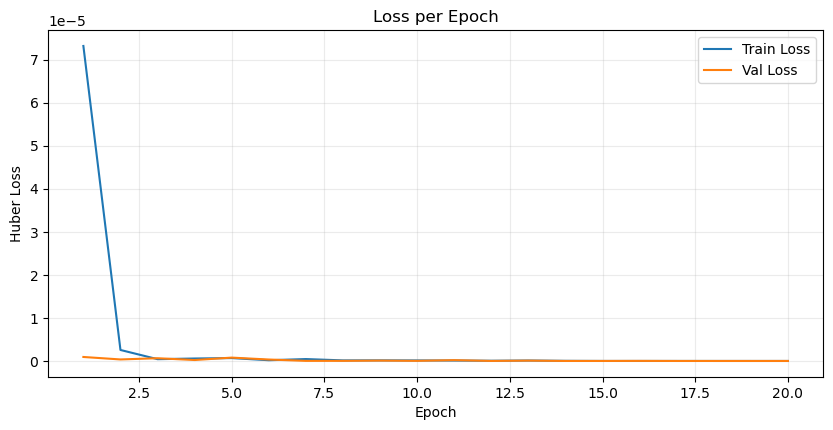

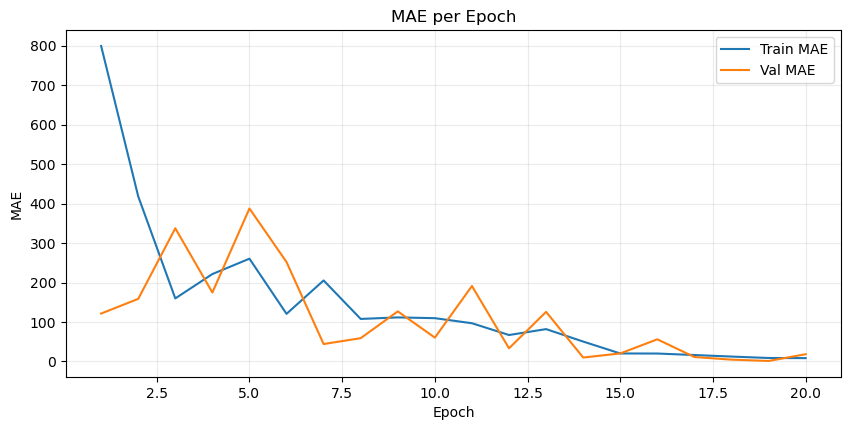

In [14]:
epochs = range(1, len(history['tr_loss'])+1)

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_loss'], label='Train Loss')
plt.plot(epochs, history['va_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.title('Loss per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_mae'], label='Train MAE')
plt.plot(epochs, history['va_mae'], label='Val MAE')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('MAE per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

# See how good the model

In [24]:
# --- CPU-only normalization constants (safe inside DataLoader workers)
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

def letterbox_im_with_meta(im: Image.Image, max_side=672, fill=0):
    w0, h0 = im.size
    scale = max_side / max(w0, h0)
    new_w, new_h = int(round(w0 * scale)), int(round(h0 * scale))
    im_resized = im.resize((new_w, new_h), resample=Image.BICUBIC, reducing_gap=1.0)

    pad_w, pad_h = max_side - new_w, max_side - new_h
    pad_left  = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top   = pad_h // 2
    pad_bottom= pad_h - pad_top
    im_out = ImageOps.expand(im_resized, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return im_out, (scale, pad_left, pad_top, new_w, new_h, w0, h0)

def parse_points_any(d):
    """Return list of (x,y) as floats from various JSON formats."""
    pts = d.get("points", [])
    out = []
    for p in pts:
        try:
            # [x,y] as strings or numbers
            if isinstance(p, (list, tuple)) and len(p) >= 2:
                x, y = float(p[0]), float(p[1])
                out.append((x, y))
            # {"x":..., "y":...}
            elif isinstance(p, dict) and "x" in p and "y" in p:
                x, y = float(p["x"]), float(p["y"])
                out.append((x, y))
        except Exception:
            continue
    return out

def make_density_map(img_h, img_w, points_xy, sigma=4.0):
    dm = np.zeros((img_h, img_w), dtype=np.float32)
    valid = 0
    for x, y in points_xy:
        xi, yi = int(round(x)), int(round(y))
        if 0 <= xi < img_w and 0 <= yi < img_h:
            dm[yi, xi] = 1.0
            valid += 1
    if valid > 0:
        dm = cv2.GaussianBlur(dm, (0, 0), sigma)
        s = dm.sum()
        if s > 0:
            dm *= (valid / s)   # ensure sum == #points
    return dm, valid

class CrowdCountDensityDatasetEval(Dataset):
    """Returns (x, density, gt_count, name). Density may be empty if points missing."""
    def __init__(self, img_paths, lbl_paths, size, base_sigma=4.0):
        self.img_paths = img_paths
        self.lbl_paths = lbl_paths
        self.size = size
        self.base_sigma = base_sigma

    def __len__(self): return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        lbl_path = self.lbl_paths[idx]
        img = Image.open(img_path).convert("RGB")

        img, (scale, pad_l, pad_t, nw, nh, w0, h0) = letterbox_im_with_meta(img, max_side=self.size)
        W, H = img.size

        # to tensor + CPU normalization (important: NOT CUDA tensors here)
        x = TF.to_tensor(img)
        x = TF.normalize(x, NORM_MEAN, NORM_STD)

        # read json
        with open(lbl_path, "r") as f:
            d = json.load(f)

        # (1) robust count
        gt_count = None
        if "human_num" in d and isinstance(d["human_num"], (int, float)):
            gt_count = float(d["human_num"])

        # (2) robust points
        pts = parse_points_any(d)
        # transform to letterboxed coords
        pts_lb = [(px * scale + pad_l, py * scale + pad_t) for (px, py) in pts]

        # build density
        sigma = max(1.5, self.base_sigma * scale)
        dm, in_bounds = make_density_map(H, W, pts_lb, sigma=sigma)
        y = torch.from_numpy(dm.astype(np.float32)).unsqueeze(0)  # [1,H,W]

        # if gt_count missing, fall back to number of points (not in-bounds only)
        if gt_count is None:
            gt_count = float(len(pts))

        # you may also choose to use in_bounds instead of len(pts) if you want
        # gt_count = float(in_bounds)

        return x, y, gt_count, img_path.name

# ---- rebuild fresh val split (same indices you used for training)
train_imgs = sorted([p for p in TRAIN_IMG_DIR.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
train_lbls = [TRAIN_LBL_DIR / f"{p.stem}.json" for p in train_imgs]

va_imgs = [train_imgs[i] for i in val_idx]
va_lbls = [train_lbls[i] for i in val_idx]

base_va = CrowdCountDensityDatasetEval(va_imgs, va_lbls, size=IM_SIZE, base_sigma=4.0)

# single-process loader for sanity & eval (avoid CUDA init in workers)
va_loader_clean = DataLoader(base_va, batch_size=2, shuffle=False,
                             num_workers=0, pin_memory=False, drop_last=False)

# Sanity: check first batch densities and counts
xb, yb, gtb, nb = next(iter(va_loader_clean))
print("xb:", xb.shape, "yb:", yb.shape,
      "GT counts:", gtb.tolist(),
      "density sums:", yb.sum(dim=[1,2,3]).tolist())


xb: torch.Size([2, 3, 672, 672]) yb: torch.Size([2, 1, 672, 672]) GT counts: [6.0, 12.0] density sums: [6.000000953674316, 12.0]


/tmp/ipykernel_31007/2498194334.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Validation MAE (vs JSON counts): 121.54


/tmp/ipykernel_31007/2498194334.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


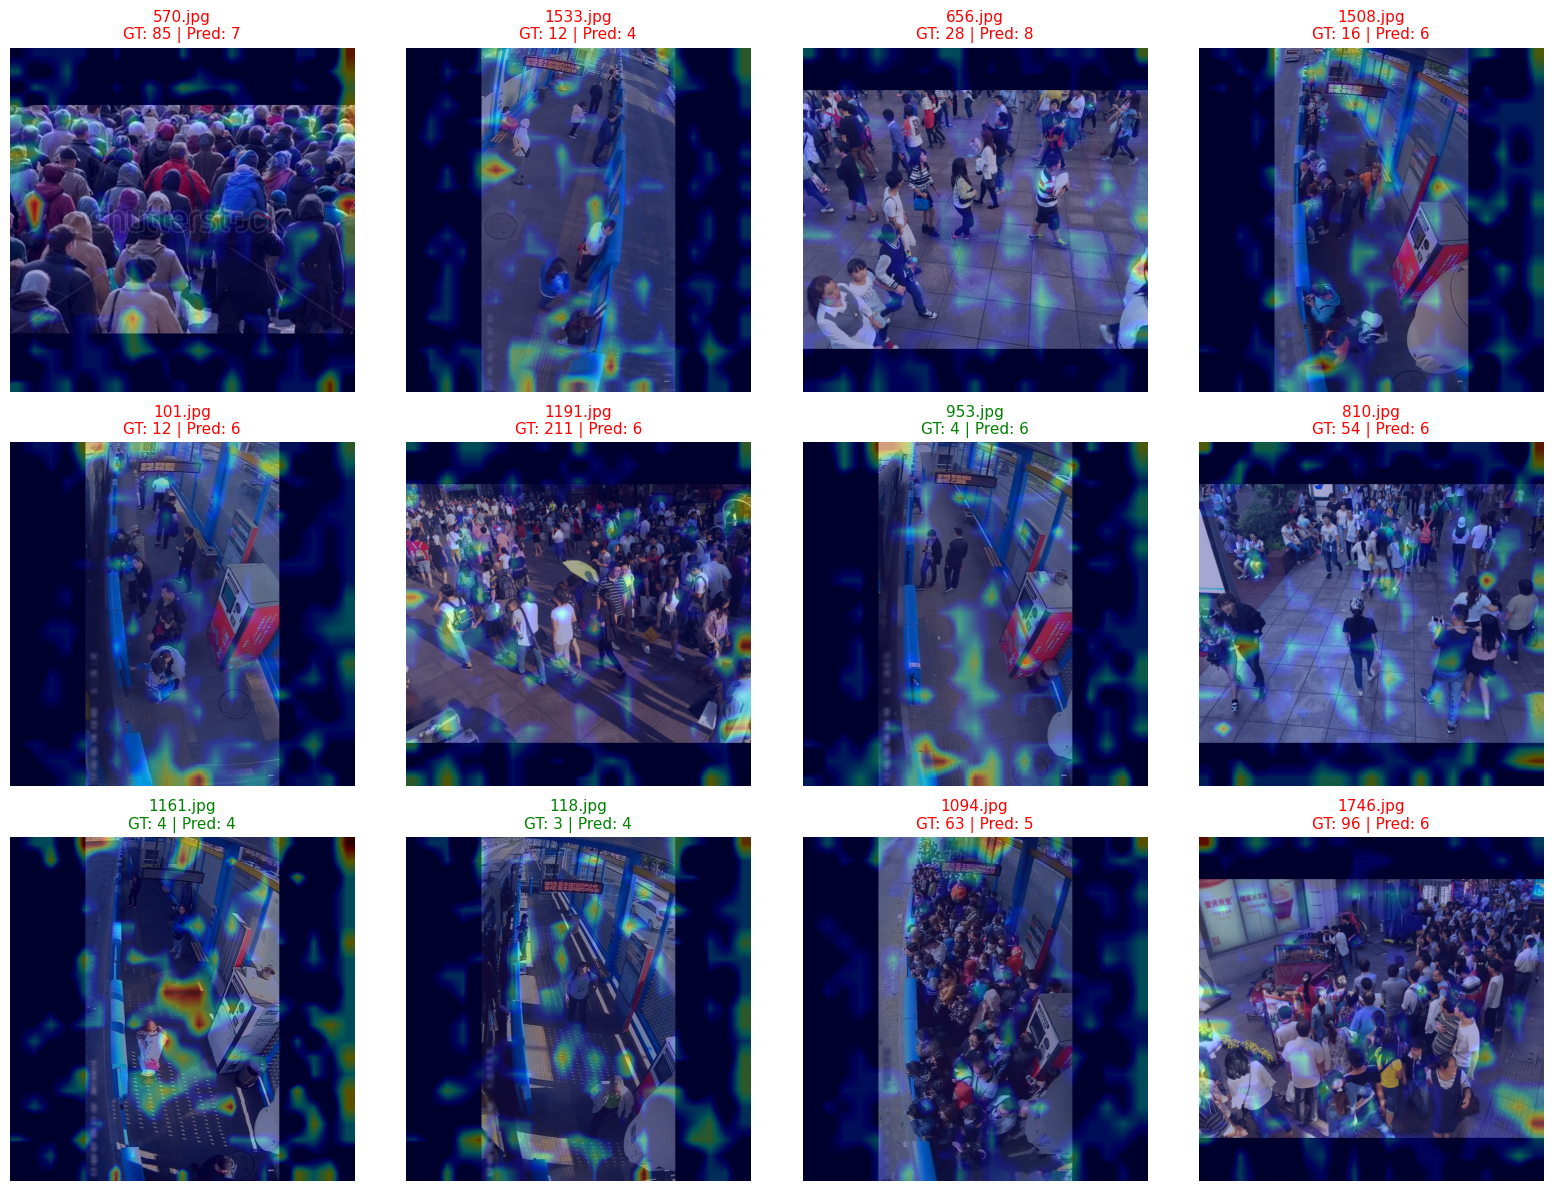

In [25]:
# reload best weights
ckpt = torch.load(BEST_PATH, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device).eval()
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

@torch.no_grad()
def batch_mae_counts(pred_map, gt_counts):
    """pred_map: [B,1,H,W], gt_counts: tensor/list length B"""
    if isinstance(gt_counts, list):
        gt_counts = torch.tensor(gt_counts, dtype=torch.float32, device=pred_map.device)
    pred_cnt = pred_map.flatten(1).sum(dim=1)
    return (pred_cnt - gt_counts).abs().sum().item()

# MAE on whole val set (using JSON count as target)
va_mae, n_va = 0.0, 0
with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    for x, y, gt_count, _ in va_loader_clean:
        if CHANNELS_LAST:
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)
        gt_count = gt_count.to(device if torch.cuda.is_available() else "cpu")
        pred = model(x).clamp_min(0)    # [B,1,H,W]
        va_mae += batch_mae_counts(pred, gt_count)
        n_va   += x.size(0)

print(f"Validation MAE (vs JSON counts): {va_mae / max(1, n_va):.2f}")

# ---- visualization utilities (GPU tensors ONLY here)
MEAN_T = torch.tensor(NORM_MEAN).view(3,1,1).to(device)
STD_T  = torch.tensor(NORM_STD).view(3,1,1).to(device)

def denorm(img_t):
    x = img_t * STD_T.to(img_t.device) + MEAN_T.to(img_t.device)
    return x.clamp(0,1).permute(1,2,0).detach().cpu().numpy()

def good_color(pred_cnt, gt_cnt):
    thr = max(5.0, 0.05 * float(gt_cnt))
    return 'green' if abs(float(pred_cnt) - float(gt_cnt)) <= thr else 'red'

# pick 12 random samples directly from base_va
NROWS, NCOLS = 3, 4
idxs = random.sample(range(len(base_va)), k=min(NROWS*NCOLS, len(base_va)))

xs, ys, gts, names = [], [], [], []
for i in idxs:
    x, y, gt_count, name = base_va[i]
    xs.append(x); ys.append(y); gts.append(gt_count); names.append(name)

# batch predict
pred_maps = []
micro = 2
with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    for s in range(0, len(xs), micro):
        batch_x = torch.stack(xs[s:s+micro], dim=0)
        if CHANNELS_LAST:
            batch_x = batch_x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            batch_x = batch_x.to(device, non_blocking=True)
        pred = model(batch_x).clamp_min(0)
        pmaps = pred.squeeze(1).detach().cpu().numpy()
        pred_maps.extend([p for p in pmaps])

pred_counts = [float(np.sum(p)) for p in pred_maps]

# plot grid
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, 12))
axes = axes.flatten()
for ax, x, pmap, name, gt_cnt, pr_cnt in zip(axes, xs, pred_maps, names, gts, pred_counts):
    rgb = denorm(x.to(device if next(model.parameters()).is_cuda else 'cpu'))
    ax.imshow(rgb)
    show_map = (pmap / (pmap.max() + 1e-6)) if pmap.max() > 0 else pmap
    ax.imshow(show_map, cmap='jet', alpha=0.35, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{name}\nGT: {int(round(gt_cnt))} | Pred: {int(round(pr_cnt))}",
                 color=good_color(pr_cnt, gt_cnt), fontsize=11)
plt.tight_layout()
plt.show()


# TEST DATASET AND PRED

In [26]:
# ---- paths (your existing ones) ----
TEST_IMG_DIR  = Path("../Datasets/test/images/")
SUBMIT_DIR    = Path("../Submission"); SUBMIT_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH     = OUTPUT_DIR / "best_swin_density.pth"  # same as training

# ---- image size & normalization (CPU lists, safe for DataLoader workers) ----
IM_SIZE   = IM_SIZE  # keep same as training (e.g., 672)
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

# ---- letterbox identical to training (no point-transform needed for test) ----
def letterbox_im_with_meta(im: Image.Image, max_side=672, fill=0):
    w0, h0 = im.size
    scale = max_side / max(w0, h0)
    new_w, new_h = int(round(w0 * scale)), int(round(h0 * scale))
    im_resized = im.resize((new_w, new_h), resample=Image.BICUBIC, reducing_gap=1.0)
    pad_w, pad_h = max_side - new_w, max_side - new_h
    pad_left  = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top   = pad_h // 2
    pad_bottom= pad_h - pad_top
    im_out = ImageOps.expand(im_resized, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return im_out

# ---- test dataset ----
class CrowdTestDataset(Dataset):
    def __init__(self, img_dir: Path, size=IM_SIZE):
        self.size = size
        self.imgs = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        p = self.imgs[idx]
        im = Image.open(p).convert("RGB")
        im = letterbox_im_with_meta(im, max_side=self.size)
        x = TF.to_tensor(im)
        x = TF.normalize(x, NORM_MEAN, NORM_STD)
        return x, p.name

# ---- build dataloader ----
BATCH_SIZE   = max(1, min(8, os.cpu_count() or 2))  # small & safe
NUM_WORKERS  = 0  # avoid CUDA init in workers; inference is light anyway
CHANNELS_LAST = globals().get("CHANNELS_LAST", True)

ds_te = CrowdTestDataset(TEST_IMG_DIR, size=IM_SIZE)
dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

print(f"Found {len(ds_te)} test images.")

# ---- (Re)build model if not present; then load best weights ----
if 'model' not in globals():
    # expect you defined SwinDensityNet earlier; otherwise import/define it here
    try:
        model = SwinDensityNet(img_size=IM_SIZE, pretrained=False)
    except NameError as e:
        raise RuntimeError("SwinDensityNet class is not in scope. Run the model definition cell first.") from e

ckpt = torch.load(BEST_PATH, map_location="cpu")
model.load_state_dict(ckpt["model"])
model = model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu")).eval()
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

device = next(model.parameters()).device

# ---- inference: works for density-map models AND scalar regressors ----
pred_rows = []
with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    for x, names in dl_te:
        if CHANNELS_LAST:
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)

        yhat = model(x)

        # If density map: [B,1,H,W] -> sum per image; if scalar: [B,1]/[B] -> squeeze
        if yhat.dim() == 4:
            counts = yhat.clamp_min(0).flatten(1).sum(dim=1)  # sum density -> count
        else:
            counts = yhat.squeeze().clamp_min(0).float()

        counts = counts.detach().cpu().numpy().astype(float)
        for name, pred in zip(names, counts):
            pred_rows.append((name, float(pred)))

# ---- write CSV matching sample template if present ----
import pandas as pd

candidate_samples = [
    Path("../sample_submission.csv"),
    Path("../Datasets/sample_submission.csv"),
    Path("../Submission/sample_submission.csv"),
    Path("sample_submission.csv"),
    Path("/mnt/data/sample_submission.csv"),
]
sample_path = next((p for p in candidate_samples if p.exists()), None)

out_path = SUBMIT_DIR / "submission_swin_density.csv"

if sample_path is not None:
    sub = pd.read_csv(sample_path)
    key, outcol = sub.columns[:2]  # assume first is image_id, second is count
    pred_map = {k: v for k, v in pred_rows}
    # Round to nearest integer for Kaggle (change if competition spec differs)
    sub[outcol] = sub[key].map(lambda k: int(round(pred_map.get(k, 0.0))))
    sub.to_csv(out_path, index=False)
else:
    # Fallback: alphabetical order; columns: image_id,count
    rows = sorted(pred_rows, key=lambda kv: kv[0].lower())
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["image_id","count"])
        for k, v in rows:
            w.writerow([k, int(round(v))])

print("Wrote submission to:", out_path)


Found 500 test images.


/tmp/ipykernel_31007/202428889.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Wrote submission to: ../Submission/submission_swin_density.csv
